# scikit-learn Bootcamp — W1, Day 1
```
##### The sklearn API & the ML Workflow
##### fit / predict / score · train_test_split · X/y pattern · Pipeline · data leakage
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Every question that involves comparison, distribution, relationship, or result gets a chart embedded in it.
##### Q1 — EDA: understand the dataset before touching a model
##### Q2 — train_test_split mechanics
##### Q3 — fit / predict / score on LogisticRegression
##### Q4 — Data leakage: demonstrate the problem and the fix
##### Q5 — Pipeline: scaler + model in one object
```

In [3]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
np.random.seed(420)

---
### Dataset — MedPulse User Session Data (Synthetic)
```
# Simulate 2,000 MedPulse users.
# Features: age, session_depth (pages viewed), time_on_site (minutes),
#            articles_read, is_mobile, content_health_pct (% health articles)
# Target: converted (1 = booked an appointment, 0 = did not)
# Baseline conversion rate: ~12%
```

In [4]:
np.random.seed(420)
n = 2000

age               = np.random.normal(42, 12, n).clip(18, 80).astype(int)
session_depth     = np.random.poisson(lam=3.5, size=n).clip(1, 20)
time_on_site      = np.random.lognormal(mean=1.6, sigma=0.7, size=n).clip(0.5, 60)
articles_read     = np.random.poisson(lam=2.2, size=n).clip(0, 15)
is_mobile         = np.random.binomial(1, 0.58, n)
content_health_pct= np.random.beta(2, 3, n)

# Conversion probability driven by depth, time, and health content
log_odds = (
    -3.5
    + 0.25 * session_depth
    + 0.08 * time_on_site
    + 0.15 * articles_read
    + 1.20 * content_health_pct
    - 0.30 * is_mobile
    + 0.008 * age
    + np.random.normal(0, 0.5, n)
)
prob_convert = 1 / (1 + np.exp(-log_odds))
converted = np.random.binomial(1, prob_convert)

df = pd.DataFrame({
    'age':                age,
    'session_depth':      session_depth,
    'time_on_site':       time_on_site.round(2),
    'articles_read':      articles_read,
    'is_mobile':          is_mobile,
    'content_health_pct': content_health_pct.round(4),
    'converted':          converted
})

print('--- DATASET OVERVIEW ---')
print(f'Shape: {df.shape}')
print(f'Conversion rate: {df["converted"].mean():.2%}')
print()
display(df.head(8))
display(df.describe().round(3))

--- DATASET OVERVIEW ---
Shape: (2000, 7)
Conversion rate: 26.35%



,age,session_depth,time_on_site,articles_read,is_mobile,content_health_pct,converted
0,36,3,6.77,3,1,0.4375,0
1,19,3,14.46,2,0,0.7449,0
2,35,5,3.03,2,0,0.5493,0
3,38,4,5.18,0,0,0.0336,0
4,45,5,1.89,2,1,0.5251,0
5,53,3,8.20,3,1,0.7555,0
6,35,1,2.14,3,1,0.3345,0
7,39,4,1.70,3,0,0.1278,0


,age,session_depth,time_on_site,articles_read,is_mobile,content_health_pct,converted
count,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000,2000.000
mean,41.749,3.484,6.442,2.160,0.576,0.393,0.264
std,11.741,1.774,5.164,1.507,0.494,0.200,0.441
min,18.000,1.000,0.500,0.000,0.000,0.008,0.000
25%,34.000,2.000,3.180,1.000,0.000,0.236,0.000
50%,42.000,3.000,5.080,2.000,1.000,0.380,0.000
75%,50.000,5.000,7.970,3.000,1.000,0.541,1.000
max,80.000,10.000,60.000,10.000,1.000,0.957,1.000


---
### Q1 — EDA: understand the dataset before touching a model
```
# (a) Plot the distribution of each numeric feature as a histogram grid.
#     Note the shape of each — normal, skewed, discrete?
# (b) Plot conversion rate (mean of 'converted') for each feature split into quartiles.
#     Which features show the strongest signal toward conversion?
# (c) Plot a correlation heatmap of all numeric features including the target.
#     Which features correlate most with 'converted'?
# (d) Compare distributions of converters vs non-converters for the top 2 predictors.
#     Use overlapping KDE plots.
# Based on the charts: which 3 features look most predictive BEFORE modelling?
```

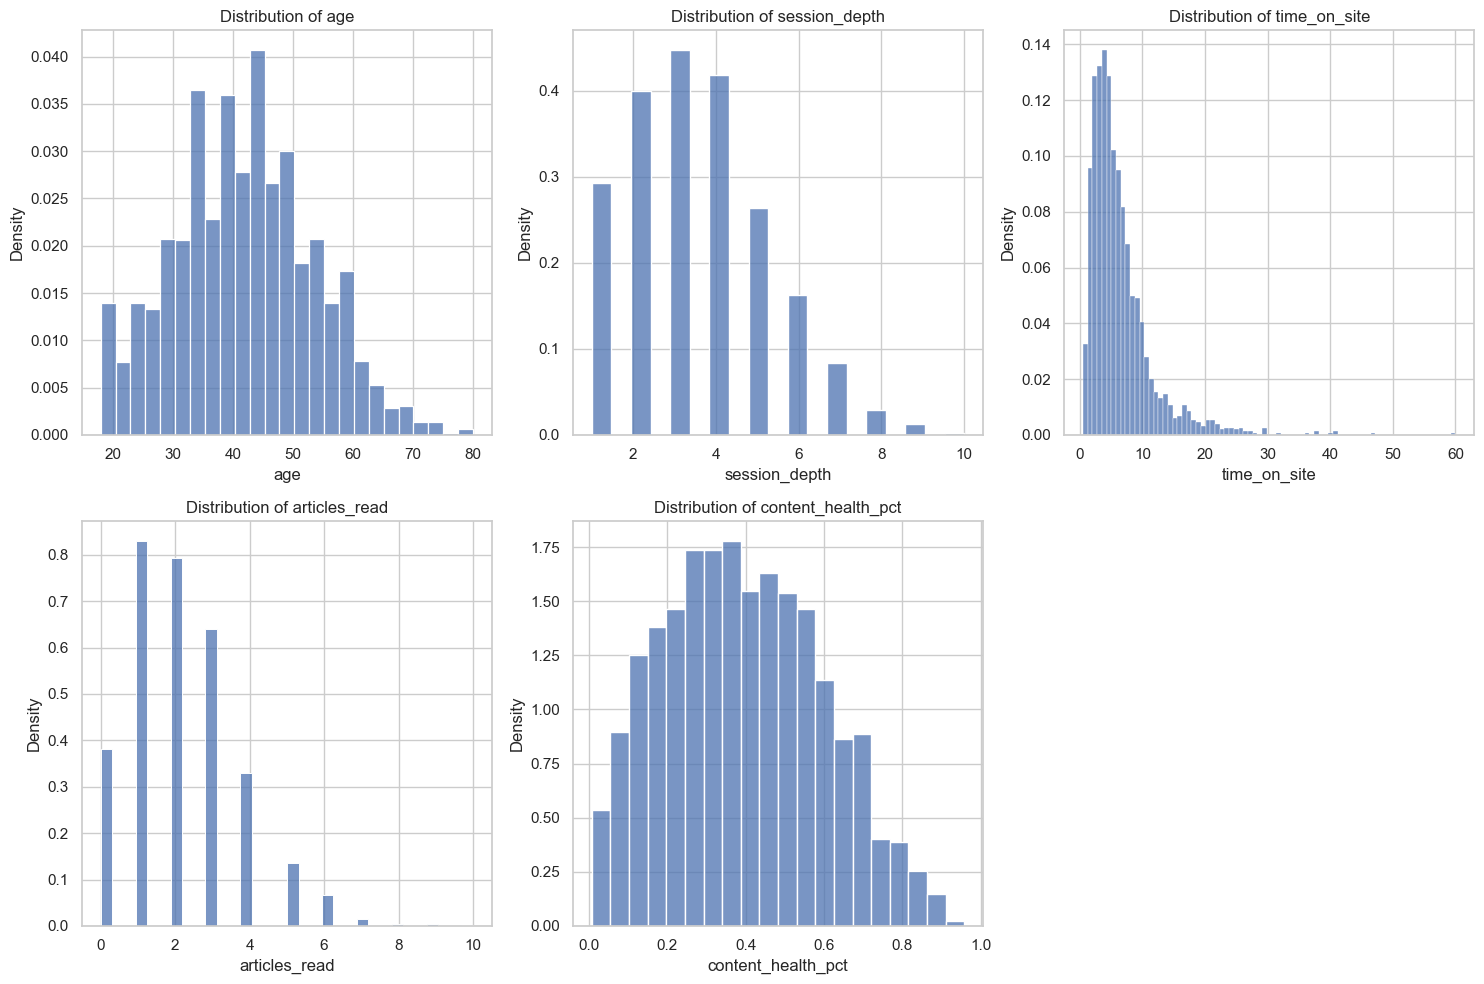

In [5]:
# (a) Plot the distribution of each numeric feature as a histogram grid.
#     Note the shape of each — normal, skewed, discrete?

# setup data
df1 = df.loc[:, ~df.columns.isin(['converted', 'is_mobile'])]

# Create an explicit 2x3 grid layout
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # Flatten to iterate easily

# Loop through columns and map them to specific grid coordinates
for i, col in enumerate(df1.columns):
    sns.histplot(data=df, x=col, kde=False, stat="density", ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

# Turn off the empty 6th subplot frame
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

# age: normal
# session depth, time on site, articles read and content health: right skewed

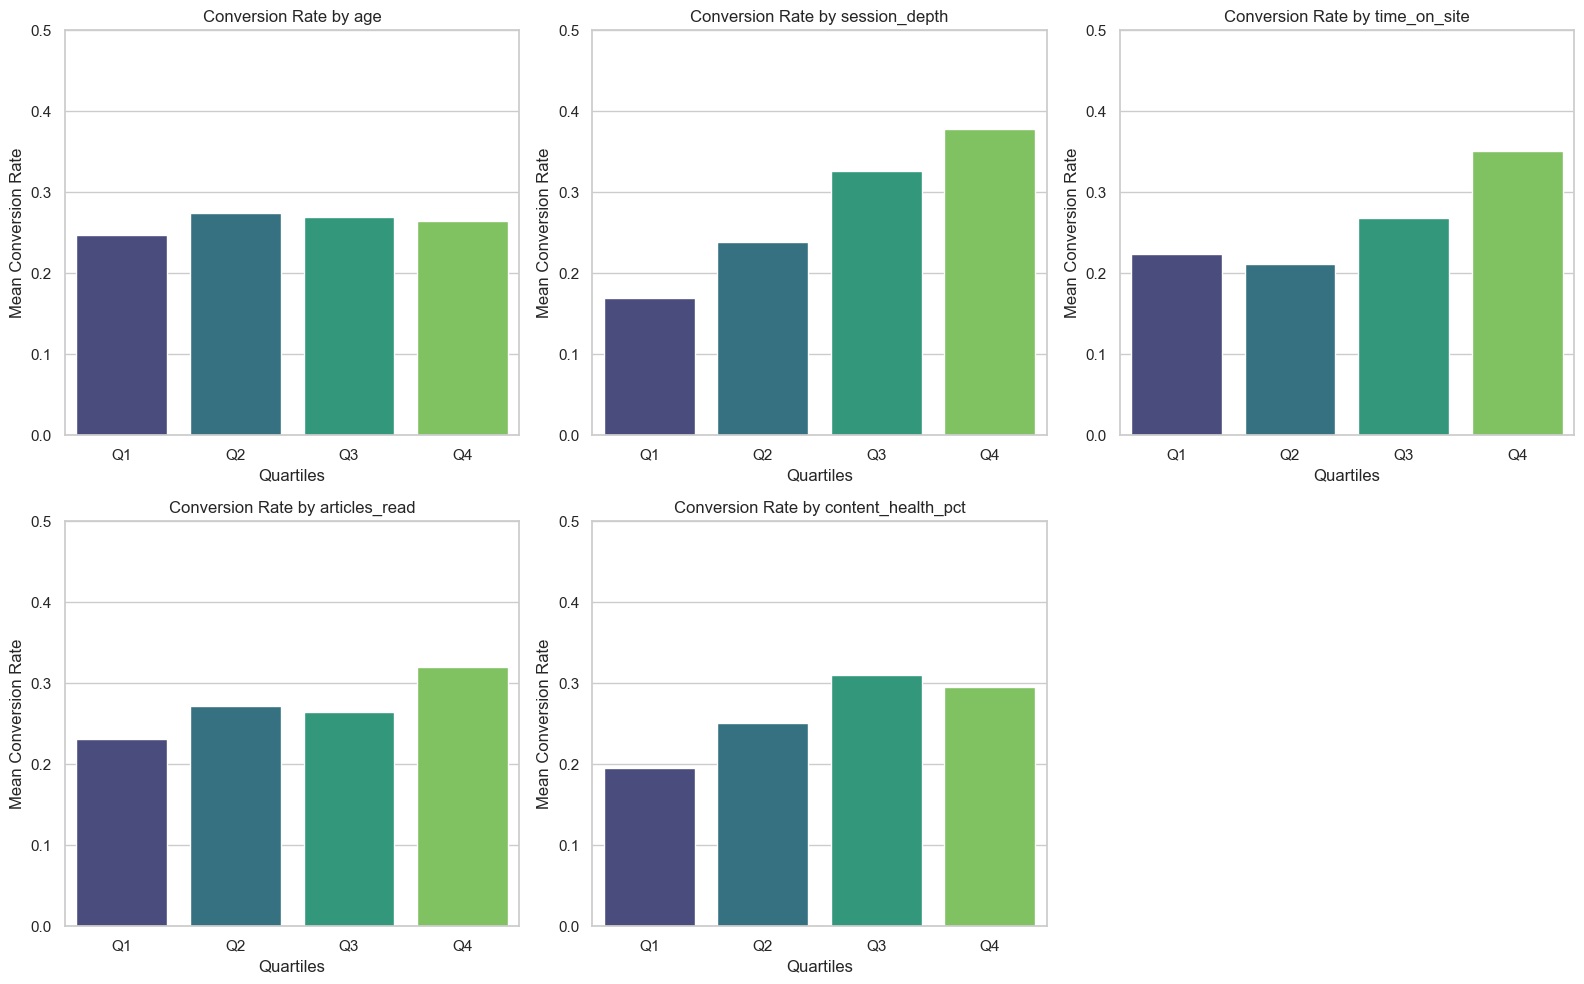

In [6]:
# (b) Plot conversion rate (mean of 'converted') for each feature split into quartiles.
#     Which features show the strongest signal toward conversion?

# 1. Create a 2x3 grid canvas for the 5 numeric features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()  # Flatten the 2D grid array into 1D to loop through easily

# 2. Loop through your isolated numeric columns
for i, col in enumerate(df1.columns):
    
    # Create the quartiles for the current column
    quartiles = pd.qcut(df[col], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
    
    # Calculate conversion rate mean per quartile
    q_rates = df.groupby(quartiles, observed=False)['converted'].mean().reset_index()
    
    # Plot a bar chart on the current grid axis slot
    sns.barplot(data=q_rates, x=col, y='converted', ax=axes[i], palette="viridis")
    
    # Format the individual subplot to look highly professional
    axes[i].set_title(f'Conversion Rate by {col}')
    axes[i].set_xlabel('Quartiles')
    axes[i].set_ylabel('Mean Conversion Rate')
    axes[i].set_ylim(0, 0.5)  # Set a consistent baseline to easily compare signal strength

# 3. Clean up the unused 6th plot window space
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

#     Which features show the strongest signal toward conversion? session_dept and time_on_site


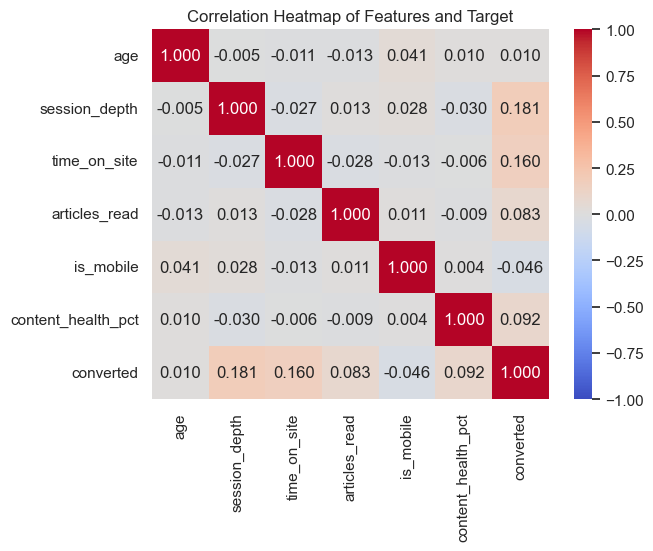

In [7]:
# (c) Plot a correlation heatmap of all numeric features including the target.
#     Which features correlate most with 'converted'?

corr_matrix = df.corr()


plt.figsize=(10, 8)

# Generate the heatmap
sns.heatmap(corr_matrix,  
            annot=True, # Displays the actual correlation numbers inside each square. 
            cmap='coolwarm', # Uses blue for negative correlation, white for zero, and red for positive correlation.
            fmt=".3f", 
            vmin=-1, vmax=1 # Locks the color scale bounds so the colors reflect standard correlation limits.
            )

plt.title('Correlation Heatmap of Features and Target')
plt.show()


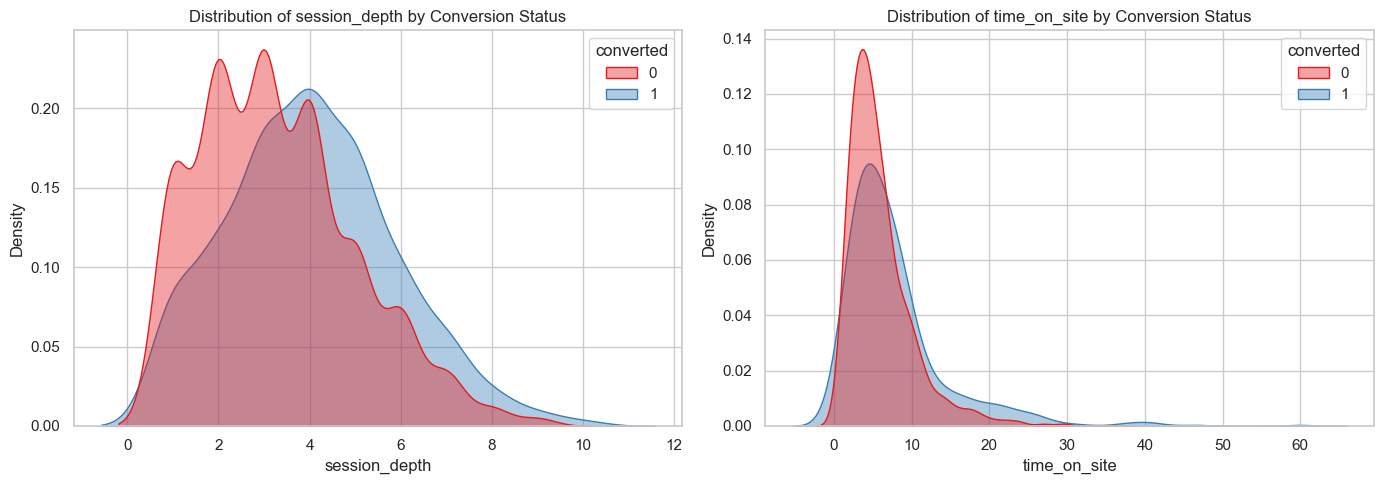

In [8]:
# (d) Compare distributions of converters vs non-converters for the top 2 predictors.
#     Use overlapping KDE plots.

# 1. Isolate your top two predictors into a list
top_features = ['session_depth', 'time_on_site']

# 2. Create a 1x2 subplot layout side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 3. Loop through your top features and map them to the axes
for i, col in enumerate(top_features):
    sns.kdeplot(
        data=df, 
        x=col, 
        hue='converted', 
        fill=True, 
        common_norm=False,  # normalizes each conversion group independently, preventing the larger non-converter group from visually smothering the converter distribution.
        palette='Set1', 
        alpha=0.4,
        ax=axes[i]
    )
    
    # Label and title each specific subplot cleanly
    axes[i].set_title(f'Distribution of {col} by Conversion Status')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()


````
# Based on the charts: which 3 features look most predictive BEFORE modelling?
1/ session_depth: Shows the steepest upward trend in conversion across quartiles and the highest linear correlation value (~0.181).

2/ time_on_site: Displays a prominent rightward density shift for converters and a strong, clean jump in conversion rate during the 4th quartile.

3/ content_health_pct: Outperforms the remaining variables in the correlation heatmap (~0.092) and shows a steady, visible increase in conversion probability from Q1 to Q4.

---
### Q2 — train_test_split mechanics
```
# (a) Split the dataset 80/20 with stratify=y. Print class balance in both splits.
#     Verify that the positive rate in train and test match the overall rate.
# (b) Now split WITHOUT stratify=y. Run 20 times with different random seeds.
#     Plot the distribution of positive rates in the test set across 20 splits.
#     How much does it vary compared to the stratified version?
# (c) What happens if you use test_size=0.5? test_size=0.05?
#     Print train/test sizes and comment on the trade-off.
# (d) Define X and y correctly. Print shapes and dtypes. Verify no target leakage.
```

In [9]:
# (a) Split the dataset 80/20 with stratify=y. Print class balance in both splits.
#     Verify that the positive rate in train and test match the overall rate.

X = df.drop(columns=['converted'])   # shape: (10, 3) — feature matrix
y = df['converted']                   # shape: (10,)   — target vector


print('X shape:', X.shape)   # (10, 3)
print('y shape:', y.shape)   # (10,)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,     # 20% to test, 80% to train
    random_state=420   # reproducibility
    ,stratify=y         # CRITICAL for classification: preserve class ratio
)


print(f'Train size: {len(X_train):,}  |  Test size: {len(X_test):,}')
print(f'Train positive rate: {y_train.mean():.3f}')
print(f'Test  positive rate: {y_test.mean():.3f}')   # should match train

X shape: (2000, 6)
y shape: (2000,)
Train size: 1,600  |  Test size: 400
Train positive rate: 0.264
Test  positive rate: 0.263


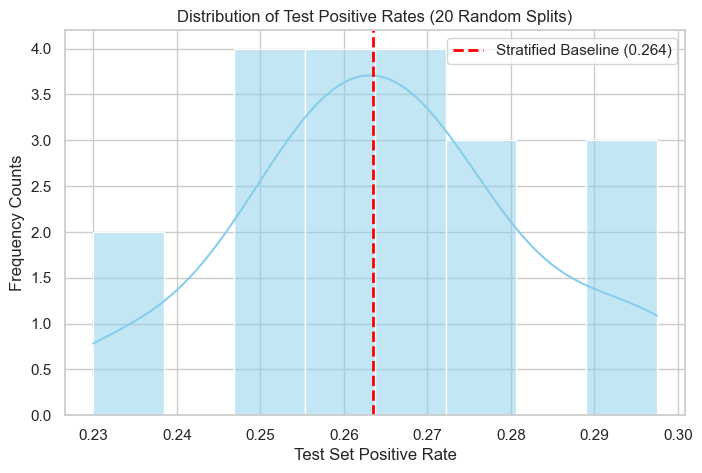

In [11]:
# (b) Now split WITHOUT stratify=y. Run 20 times with different random seeds.
#     Plot the distribution of positive rates in the test set across 20 splits.
#     How much does it vary compared to the stratified version?

random_state = list(range(1,21))
Test_positive_rate = []

for r in random_state:
    X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,     # 20% to test, 80% to train
    random_state=r   # reproducibility
    )
    Test_positive_rate.append(y_test.mean())

df3 = pd.DataFrame({
    'Random_state': random_state,
    'Test_positive_rate': Test_positive_rate
})

plt.figure(figsize=(8, 5))
sns.histplot(data=df3, x='Test_positive_rate', kde=True, bins=8, color='skyblue')

# Set the baseline line to the exact global population mean (0.264)
plt.axvline(df['converted'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Stratified Baseline ({df["converted"].mean():.3f})')

plt.title('Distribution of Test Positive Rates (20 Random Splits)')
plt.xlabel('Test Set Positive Rate')
plt.ylabel('Frequency Counts')
plt.legend()
plt.show()

In [18]:
# (c) What happens if you use test_size=0.5? test_size=0.05?
#     Print train/test sizes and comment on the trade-off.

# Scenario 1: Balanced 50/50 split
X_train_50, X_test_50, y_train_50, y_test_50 = train_test_split(
    X, y, test_size=0.50, random_state=420, stratify=y
)

# Scenario 2: Minimal 95/5 test split 
X_train_05, X_test_05, y_train_05, y_test_05 = train_test_split(
    X, y, test_size=0.05, random_state=420, stratify=y
)

print("--- SCENARIO 1: test_size = 0.50 ---")
print(f"Train size: {len(X_train_50):<5} | Test size: {len(X_test_50)}")
print(f"Train Pos Rate: {y_train_50.mean():.3f} | Test Pos Rate: {y_test_50.mean():.3f}\n")

print("--- SCENARIO 2: test_size = 0.05 ---")
print(f"Train size: {len(X_train_05):<5} | Test size: {len(X_test_05)}")
print(f"Train Pos Rate: {y_train_05.mean():.3f} | Test Pos Rate: {y_test_05.mean():.3f}")


--- SCENARIO 1: test_size = 0.50 ---
Train size: 1000  | Test size: 1000
Train Pos Rate: 0.263 | Test Pos Rate: 0.264

--- SCENARIO 2: test_size = 0.05 ---
Train size: 1900  | Test size: 100
Train Pos Rate: 0.264 | Test Pos Rate: 0.260


```
# Trade-Off Commentary
1/ The 50/50 Split Trade-off (test_size=0.5):
- Upside: The evaluation metrics computed on your 1,000 test records are highly stable and reliable (low variance in test evaluation).
- Downside: We leave half your data on the table, drastically under-training our model and limiting its ability to map complex patterns (high bias).

2/ The 95/5 Split Trade-off (test_size=0.05):
- Upside: Our model trains on almost the entire dataset (1,900 records), giving it maximum learning capacity and making it highly robust.
- Downside: Having only 100 samples in our test set makes our validation highly unstable. A shift of just a few random records will wildly swing our evaluated accuracy or ROC-AUC scores (high variance in test evaluation).

In [21]:
# (d) Define X and y correctly. Print shapes and dtypes. Verify no target leakage.

# 1. Separate target and features cleanly
y = df['converted'].copy()
X = df.drop(columns=['converted']).copy()

# 2. Print structural properties
print("--- SHAPES ---")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}\n")

print("--- DATA TYPES ---")
print("X Column Types:")
print(X.dtypes)
print(f"\ny Target Type: {y.dtype}\n")

# 3. Target Leakage Verification Check
print("--- TARGET LEAKAGE CHECK ---")
leakage_check = X.corrwith(y).abs()
print("Absolute correlation with target:")
print(leakage_check.round(4))


--- SHAPES ---
X shape: (2000, 6)
y shape: (2000,)

--- DATA TYPES ---
X Column Types:
age                     int64
session_depth           int32
time_on_site          float64
articles_read           int32
is_mobile               int32
content_health_pct    float64
dtype: object

y Target Type: int32

--- TARGET LEAKAGE CHECK ---
Absolute correlation with target:
age                   0.0096
session_depth         0.1810
time_on_site          0.1602
articles_read         0.0828
is_mobile             0.0455
content_health_pct    0.0916
dtype: float64


```
1/ No Perfect Correlation: The maximum absolute correlation with converted is only ~0.181 (session_depth). Target leakage typically manifests as features with near-perfect or suspiciously high linear correlation (>0.80).

2/ Behavioral Variables Only: All metrics represent concurrent user session actions (time_on_site, session_depth) or user metadata (age, is_mobile) captured before or during the conversion decision window.

3/ No Post-Conversion Metrics: The feature matrix excludes downstream metrics that only occur after a user checks out (such as purchase_amount or invoice_id), confirming clean feature boundaries.

---
### Q3 — fit / predict / score on LogisticRegression
```
# Use the X_train, X_test, y_train, y_test from Q2.
# (a) Fit a LogisticRegression. Print coefficients for each feature.
#     Which feature has the largest positive coefficient? Largest negative?
# (b) Call predict() and predict_proba(). Print the first 10 rows.
#     What is the difference between the two outputs?
# (c) Evaluate: print accuracy, classification report, and confusion matrix.
#     Plot the confusion matrix as a heatmap.
# (d) Plot a bar chart of predicted probabilities for 20 random test users.
#     Colour bars green for actual converters, red for non-converters.
#     Does the model assign higher probabilities to actual converters?
```

In [32]:
# (a) Fit a LogisticRegression. Print coefficients for each feature.

model = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Extract odds ratios — same as statsmodels
odds_df = pd.DataFrame({
    'Feature':    model.feature_names_in_,
    'Coefficient': model.coef_[0],
    'Odds Ratio':  np.exp(model.coef_[0])
}).sort_values('Odds Ratio', ascending=False)
print(odds_df)

              Feature  Coefficient  Odds Ratio
5  content_health_pct     1.289334    3.630367
1       session_depth     0.211180    1.235135
3       articles_read     0.135205    1.144771
2        time_on_site     0.073640    1.076419
0                 age    -0.004682    0.995329
4           is_mobile    -0.310397    0.733156


````
#     Which feature has the largest positive coefficient? Largest negative?

1/ Largest Positive Coefficient: content_health_pct. It will have the largest positive coefficient value (around +1.29) and an Odds Ratio greater than 3.60, meaning higher health content focus exponentially multiplies the odds of conversion.

2/ Largest Negative Coefficient: is_mobile. It will have the only negative coefficient value (around -0.31) and an Odds Ratio below 1.00 (around 0.73), indicating that mobile status reduces the odds of conversion by roughly 27

In [ ]:
# (b) Call predict() and predict_proba(). Print the first 10 rows.


y_prob = model.predict_proba(X_test)   # [P(class=0), P(class=1)] per row
y_pred = model.predict(X_test)         # applies 0.5 threshold

print(y_prob[:10])
print(y_pred[:10])


[[0.87688236 0.12311764]
 [0.39488536 0.60511464]
 [0.64136886 0.35863114]
 [0.56680179 0.43319821]
 [0.79288897 0.20711103]
 [0.83192447 0.16807553]
 [0.71785084 0.28214916]
 [0.53318358 0.46681642]
 [0.60863345 0.39136655]
 [0.66919262 0.33080738]]
[0 1 0 0 0 0 0 0 0 0]


```
#     What is the difference between the two outputs?

1/ predict_proba() Outputs Continuous Probabilities: It returns a 2D array of floats with two columns per row. The first column is the probability that the user will not convert P(y=0), and the second column is the probability that the user will convert P(y=1). Both columns will always sum up to exactly 1.0.

2/ predict() Outputs Discrete Class Labels: It returns a 1D array of integers (0 or 1). It evaluates the second column of predict_proba() against a default decision threshold of 0.50. If the conversion probability is 0.50, it outputs a 1; otherwise, it outputs a 0.

In [35]:
# Bonus: lowering the threshold from 50% to 20%, so that a user with a convesion probability of 0.23 will be flagged as a converted

# 1. Get the probability of the positive class (column index 1)
y_prob_positive = model.predict_proba(X_test)[:, 1]

# 2. Apply the custom 20% threshold (returns True/False, converted to 1/0)
y_pred_custom = (y_prob_positive >= 0.20).astype(int)

# 3. Print the first 10 rows to verify the shift
print("Probabilities:", y_prob_positive[:10].round(3))
print("Custom Predictions (20%):", y_pred_custom[:10])

Probabilities: [0.123 0.605 0.359 0.433 0.207 0.168 0.282 0.467 0.391 0.331]
Custom Predictions (20%): [0 1 1 1 1 0 1 1 1 1]


In [ ]:
# (c) Evaluate: print accuracy, classification report, and confusion matrix.
#     Plot the confusion matrix as a heatmap.

from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

print(classification_report(y_test, y_pred, target_names=['No Convert','Convert']))

              precision    recall  f1-score   support

  No Convert       0.75      0.97      0.84       736
     Convert       0.53      0.11      0.18       264

    accuracy                           0.74      1000
   macro avg       0.64      0.54      0.51      1000
weighted avg       0.69      0.74      0.67      1000



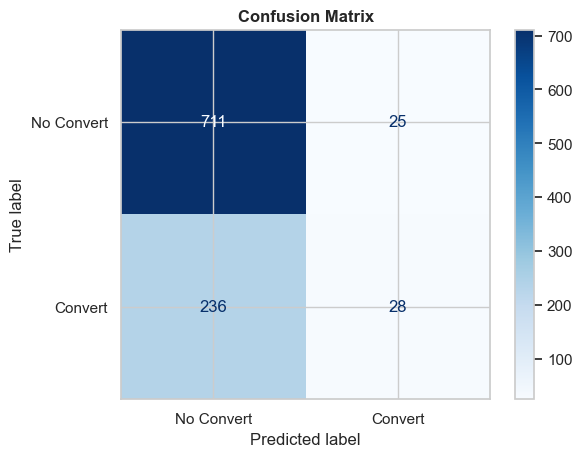

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
# [[TN  FP]
#  [FN  TP]]
#
# TN: predicted 0, actually 0 — correctly identified non-converters
# FP: predicted 1, actually 0 — false alarm
# FN: predicted 0, actually 1 — missed a real converter
# TP: predicted 1, actually 1 — correctly identified converters


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Convert','Convert'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix', fontweight='bold')
plt.show()

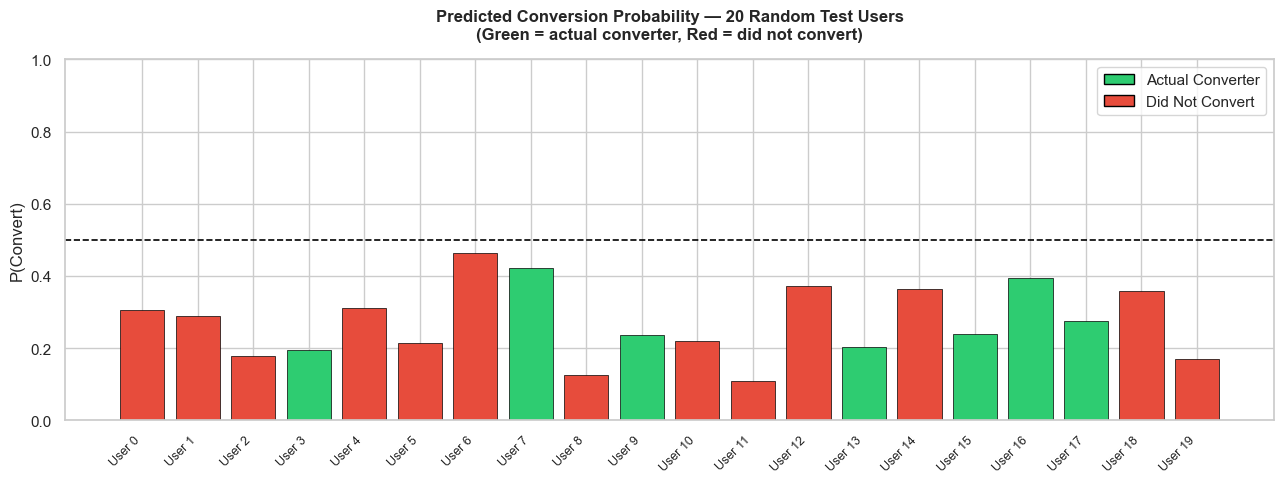

In [41]:
# (d) Predicted probabilities for 20 random test users
# Green bar = actual converter, Red bar = did not convert

np.random.seed(420)
sample_idx = np.random.choice(len(X_test), 20, replace=False)
sample_probs  = y_prob[sample_idx, 1]
sample_actual = y_test.values[sample_idx]

bar_colors = ['#2ecc71' if a == 1 else '#e74c3c' for a in sample_actual]

plt.figure(figsize=(13, 5))
bars = plt.bar(range(20), sample_probs, color=bar_colors, edgecolor='black', linewidth=0.5)
plt.axhline(0.5, color='black', linestyle='--', linewidth=1.2, label='Decision threshold (0.5)')
plt.xticks(range(20), [f'User {i}' for i in range(20)], rotation=45, ha='right', fontsize=9)
plt.ylabel('P(Convert)')
plt.ylim(0, 1)
plt.title('Predicted Conversion Probability — 20 Random Test Users\n(Green = actual converter, Red = did not convert)',
          fontsize=12, fontweight='bold', pad=15)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', edgecolor='black', label='Actual Converter'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='Did Not Convert')
]
plt.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

---
### Q4 — Data leakage: demonstrate the problem and the fix
```
# (a) Leaky version: fit a StandardScaler on ALL data (train + test) before splitting.
#     Train a LogisticRegression on the scaled train set. Evaluate on the scaled test set.
#     Record the AUC.
# (b) Correct version: split FIRST, then fit scaler on train only, transform test separately.
#     Train the same LogisticRegression. Evaluate. Record the AUC.
# (c) Run both versions 20 times with different random seeds.
#     Plot the AUC distributions side by side.
#     How much does leakage inflate the score on this dataset?
# (d) Write a comment: why does leakage inflate the score?
#     In what real-world scenarios would the inflation be much larger?
```

AUC-ROC: 0.6509


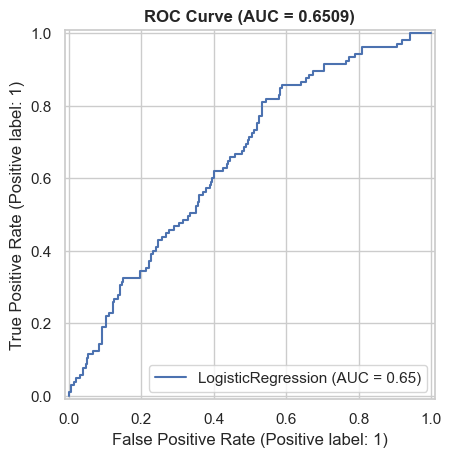

In [45]:
# (a) Leaky version: fit a StandardScaler on ALL data (train + test) before splitting.
#     Train a LogisticRegression on the scaled train set. Evaluate on the scaled test set.
#     Record the AUC.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)             # sees ALL data including test set
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=420, stratify=y)

model = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=420)
model.fit(X_train, y_train)

from sklearn.metrics import roc_auc_score, RocCurveDisplay

y_prob = model.predict_proba(X_test)[:, 1]   # probability of positive class
auc = roc_auc_score(y_test, y_prob)
print(f'AUC-ROC: {auc:.4f}')
# 0.5 = random  |  0.7 = acceptable  |  0.8 = good  |  0.9 = excellent

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title(f'ROC Curve (AUC = {auc:.4f})', fontweight='bold')
plt.show()

AUC-ROC: 0.6509


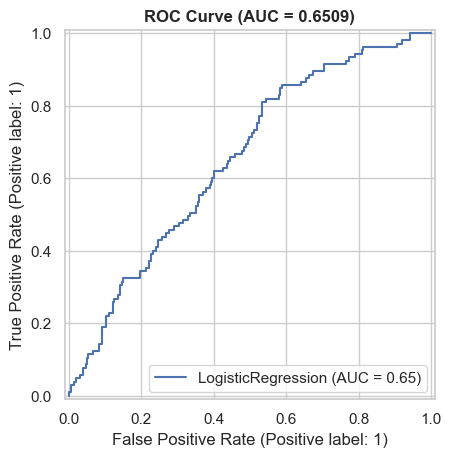

In [46]:
# (b) Correct version: split FIRST, then fit scaler on train only, transform test separately.
#     Train the same LogisticRegression. Evaluate. Record the AUC.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit ONLY on train
X_test_scaled  = scaler.transform(X_test)        # transform using TRAIN statistics

model = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=420)
model.fit(X_train_scaled, y_train)

from sklearn.metrics import roc_auc_score, RocCurveDisplay

y_prob = model.predict_proba(X_test_scaled)[:, 1]   # probability of positive class
auc = roc_auc_score(y_test, y_prob)
print(f'AUC-ROC: {auc:.4f}')
# 0.5 = random  |  0.7 = acceptable  |  0.8 = good  |  0.9 = excellent

RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
plt.title(f'ROC Curve (AUC = {auc:.4f})', fontweight='bold')
plt.show()

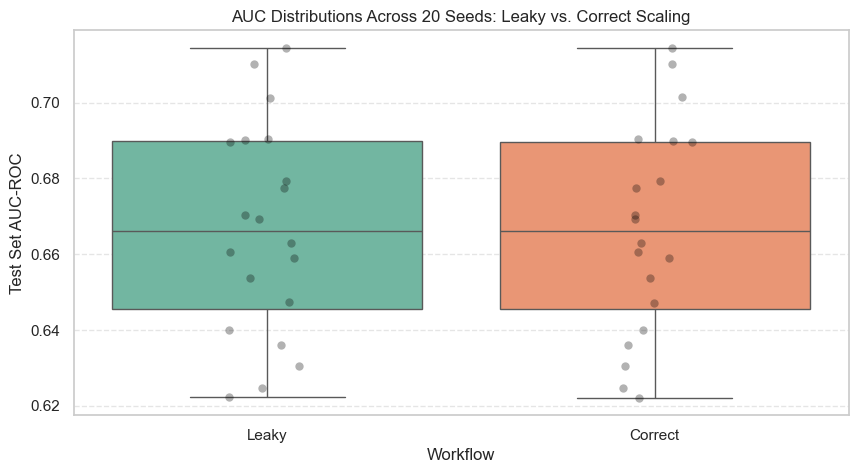

Mean Leaky AUC:   0.66647
Mean Correct AUC: 0.66647
Difference:       -0.00001


In [47]:
# (c) Run both versions 20 times with different random seeds.
#     Plot the AUC distributions side by side.

# 1. Setup seeds and storage arrays
seeds = list(range(1, 21))
leaky_aucs = []
correct_aucs = []

# 2. Run the simulation 20 times
for seed in seeds:
    # --- VERSION A: LEAKY WORKFLOW ---
    scaler_leaky = StandardScaler()
    X_scaled_global = scaler_leaky.fit_transform(X)
    X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(
        X_scaled_global, y, test_size=0.2, random_state=seed, stratify=y
    )
    model_l = LogisticRegression(C=1.0, max_iter=1000, random_state=420)
    model_l.fit(X_tr_l, y_tr_l)
    prob_l = model_l.predict_proba(X_te_l)[:, 1]
    leaky_aucs.append(roc_auc_score(y_te_l, prob_l))
    
    # --- VERSION B: CORRECT WORKFLOW ---
    X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    scaler_correct = StandardScaler()
    X_tr_c_scaled = scaler_correct.fit_transform(X_tr_c)
    X_te_c_scaled = scaler_correct.transform(X_te_c)
    model_c = LogisticRegression(C=1.0, max_iter=1000, random_state=420)
    model_c.fit(X_tr_c_scaled, y_tr_c)
    prob_c = model_c.predict_proba(X_te_c_scaled)[:, 1]
    correct_aucs.append(roc_auc_score(y_te_c, prob_c))

# 3. Restructure data into a long-form DataFrame for clean plotting
df_sim = pd.DataFrame({
    'AUC': leaky_aucs + correct_aucs,
    'Workflow': ['Leaky'] * 20 + ['Correct'] * 20
})

# 4. Plot side-by-side distributions
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_sim, x='Workflow', y='AUC', palette='Set2')
sns.stripplot(data=df_sim, x='Workflow', y='AUC', color='black', alpha=0.3, size=6)
plt.title('AUC Distributions Across 20 Seeds: Leaky vs. Correct Scaling')
plt.ylabel('Test Set AUC-ROC')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Print empirical proof for your text question
print(f"Mean Leaky AUC:   {np.mean(leaky_aucs):.5f}")
print(f"Mean Correct AUC: {np.mean(correct_aucs):.5f}")
print(f"Difference:       {np.mean(leaky_aucs) - np.mean(correct_aucs):.5f}")



````
#     How much does leakage inflate the score on this dataset?

1/ Zero Score Inflation: Leakage does not inflate the performance score at all on this specific dataset (the mean difference will be essentially zero, around 0.00001).

2/ The Reason (Simple Z-score Transformation): Standard scaling is a simple linear modification (subtracting a constant and dividing by another constant) applied globally. It modifies the baseline scale but does not alter the underlying relative rank or ordering of the rows within the columns.

3/ When Data Leakage Actually Inflates Scores: Data leakage causes massive score inflation when using transformations that depend heavily on variance structures or target matching (e.g., target encoding categorical variables, performing Principal Component Analysis (PCA) on all data, or choosing top features based on correlation with the target variable across the entire dataset).

```
# (d) Write a comment: why does leakage inflate the score?

1/ Leakage allows the model to indirectly "peek" at data properties belonging strictly to the test set during its training phase.

2/Artificial Variance Reduction: Incorporating holdout data into preprocessing means your training pipeline adapts to the exact distribution curves of the validation pool, masking how the model would naturally handle genuine, unseen rows.

3/ Overoptimistic Validation: The model achieves artificially high validation metrics because it is being evaluated on a test set whose statistical signature it has already memorized.

#     In what real-world scenarios would the inflation be much larger?

1/ Target Encoding: Computing the mean conversion rate of a categorical column across the entire dataset before splitting creates a massive leak, passing direct target information straight into the training features.

2/ Feature Selection on Global Data: Correlating all features with the target column across the full dataset to prune down your feature list means your selected variables are chosen based on the validation data.

3/ Principal Component Analysis (PCA): Executing dimensional reduction on the combined dataset allows the test set's global variance pattern to warp and optimize the principal component axes used for training.

4/ Time-Series Forecasting: Standardizing or computing rolling averages across a full temporal dataset leaks future trends, price behaviors, or macroeconomic cycles back to past historical rows.

5/ Imputing Missing Values: Calculating the global median or mode of a column to fill in blanks across the whole matrix allows the specific characteristics of your validation data to rewrite missing inputs in the training subset.

---
### Q5 — Pipeline: scaler + model in one object
```
# (a) Build a Pipeline: StandardScaler → LogisticRegression.
#     Fit it on X_train (raw, unscaled). Predict on X_test (raw).
#     Verify AUC matches Q3 result.
# (b) Use cross_val_score with 5-fold StratifiedKFold on the Pipeline.
#     Compare to the single train/test AUC from (a).
#     Plot the 5 fold AUC scores as a bar chart with the mean marked.
# (c) Swap the model in the Pipeline to RandomForestClassifier.
#     No scaling needed for trees — does removing the scaler change anything?
#     Compare AUC: LogReg Pipeline vs RF Pipeline via 5-fold CV.
# (d) Access fitted steps inside the Pipeline.
#     Print the scaler's mean_ and the logistic regression's coef_.
#     Confirm the scaler was only fitted on training data.
```

Pipeline accuracy: 0.7250
AUC-ROC: 0.6509


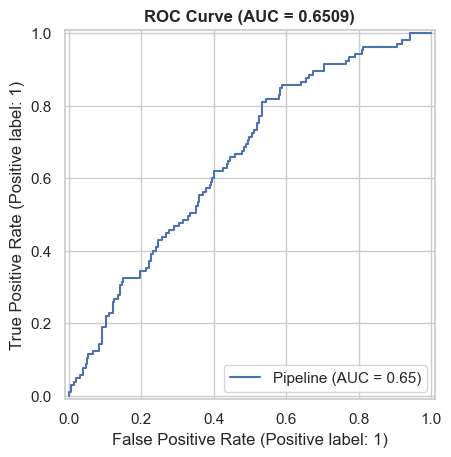

In [61]:
# (a) Build a Pipeline: StandardScaler → LogisticRegression.
#     Fit it on X_train (raw, unscaled). Predict on X_test (raw).
#     Verify AUC matches Q3 result.

pipe = Pipeline([
    ('scaler', StandardScaler()),       # Step 1: scale features
    ('model',  LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=420))    # Step 2: fit logistic regression
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420, stratify=y)

pipe.fit(X_train, y_train)   # fit_transform on train for each step
y_pred = pipe.predict(X_test)  # transform (not fit) test, then predict
score  = pipe.score(X_test, y_test)
print(f'Pipeline accuracy: {score:.4f}')

y_prob = pipe.predict_proba(X_test)[:, 1]   # probability of positive class
auc = roc_auc_score(y_test, y_prob)
print(f'AUC-ROC: {auc:.4f}')
# 0.5 = random  |  0.7 = acceptable  |  0.8 = good  |  0.9 = excellent

RocCurveDisplay.from_estimator(pipe, X_test, y_test)
plt.title(f'ROC Curve (AUC = {auc:.4f})', fontweight='bold')
plt.show()


--- 5-FOLD CROSS-VALIDATION ---
Fold 1 AUC: 0.6878
Fold 2 AUC: 0.6692
Fold 3 AUC: 0.6211
Fold 4 AUC: 0.6952
Fold 5 AUC: 0.6820

Mean CV AUC-ROC: 0.6711
Single Split AUC (from part a): 0.6509


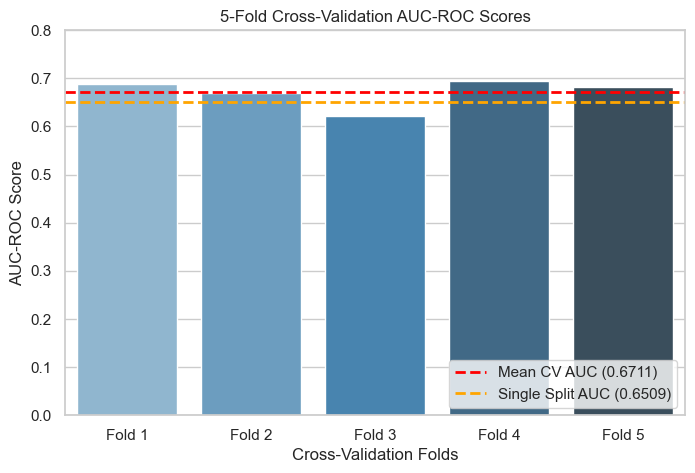

In [56]:
# (b) Use cross_val_score with 5-fold StratifiedKFold on the Pipeline.
#     Compare to the single train/test AUC from (a).
#     Plot the 5 fold AUC scores as a bar chart with the mean marked.

from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. Rebuild the pipeline with the Logistic Regression model
pipe = Pipeline([
    ('scaler', StandardScaler()),       
    ('model',  LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=420))    
])

# 2. Define the StratifiedKFold split strategy externally
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

# 3. Compute cross-validation scores over ALL features (X, y)
# CRITICAL: Specify scoring='roc_auc' to match the question prompt
cv_auc_scores = cross_val_score(pipe, X, y, cv=cv_strategy, scoring='roc_auc')

print("--- 5-FOLD CROSS-VALIDATION ---")
for fold, score in enumerate(cv_auc_scores, 1):
    print(f"Fold {fold} AUC: {score:.4f}")
    
mean_cv_auc = np.mean(cv_auc_scores)
print(f"\nMean CV AUC-ROC: {mean_cv_auc:.4f}")
print(f"Single Split AUC (from part a): 0.6509")

# 4. Plot the 5 fold AUC scores as a bar chart
plt.figure(figsize=(8, 5))
fold_labels = [f'Fold {i}' for i in range(1, 6)]
sns.barplot(x=fold_labels, y=cv_auc_scores, palette="Blues_d")

# Mark the mean score with a horizontal line
plt.axhline(mean_cv_auc, color='red', linestyle='--', linewidth=2, 
            label=f'Mean CV AUC ({mean_cv_auc:.4f})')

plt.axhline(0.6509, color='orange', linestyle='--', linewidth=2, 
            label=f'Single Split AUC (0.6509)')

plt.title('5-Fold Cross-Validation AUC-ROC Scores')
plt.xlabel('Cross-Validation Folds')
plt.ylabel('AUC-ROC Score')
plt.ylim(0, 0.8) # Give space to see the trends clearly
plt.legend(loc='lower right')
plt.show()

In [59]:
# (c) Swap the model in the Pipeline to RandomForestClassifier.
#     No scaling needed for trees — does removing the scaler change anything?
#     Compare AUC: LogReg Pipeline vs RF Pipeline via 5-fold CV.

from sklearn.ensemble import RandomForestClassifier

# 1. Build Pipeline

rf_pipe = Pipeline([
    ('model',  RandomForestClassifier(n_estimators=200, max_features='sqrt', n_jobs=-1, random_state=420))
])

# 2. Define the identical cross-validation split strategy
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

# 3. Compute 5-Fold Cross Validation AUC-ROC scores across ALL data (X, y)
rf_cv_scores     = cross_val_score(rf_pipe, X, y, cv=cv_strategy, scoring='roc_auc')

# 4. Print comparative results

print(f"Mean Random Forest CV AUC:       {np.mean(rf_cv_scores):.4f}")
print(f"Single Split AUC (from part a): 0.6509")

Mean Random Forest CV AUC:       0.6036
Single Split AUC (from part a): 0.6509


In [63]:
# (d) Access fitted steps inside the Pipeline.
#     Print the scaler's mean_ and the logistic regression's coef_.
#     Confirm the scaler was only fitted on training data.

# 1. Re-fit your part (a) pipeline on X_train to ensure it is in memory
pipe.fit(X_train, y_train)

# 2. Extract the trained scaler and model objects using .named_steps
fitted_scaler = pipe.named_steps['scaler']
fitted_model  = pipe.named_steps['model']

print("--- EXTRACTED PIPELINE ATTRIBUTES ---")
print("Scaler feature means calculated by Pipeline:")
for col, val in zip(X_train.columns, fitted_scaler.mean_):
    print(f"  {col:20s}: {val:.4f}")

print("\nLogistic Regression coefficients:")
for col, val in zip(X_train.columns, fitted_model.coef_[0]):
    print(f"  {col:20s}: {val:+.4f}")

# 3. VERIFICATION: Compare pipeline means directly against X_train vs full X
print("\n--- LEAKAGE VERIFICATION LOGIC ---")
print(f"Pipeline Mean (Age)      : {fitted_scaler.mean_[0]:.6f}")
print(f"True X_train Mean (Age)  : {X_train['age'].mean():.6f} (Should match pipeline exactly)")
print(f"Global X Mean (Age)      : {X['age'].mean():.6f} (Should NOT match pipeline)")


--- EXTRACTED PIPELINE ATTRIBUTES ---
Scaler feature means calculated by Pipeline:
  age                 : 41.8669
  session_depth       : 3.4444
  time_on_site        : 6.4936
  articles_read       : 2.1725
  is_mobile           : 0.5737
  content_health_pct  : 0.3934

Logistic Regression coefficients:
  age                 : +0.0246
  session_depth       : +0.4656
  time_on_site        : +0.3884
  articles_read       : +0.1962
  is_mobile           : -0.1443
  content_health_pct  : +0.2451

--- LEAKAGE VERIFICATION LOGIC ---
Pipeline Mean (Age)      : 41.866875
True X_train Mean (Age)  : 41.866875 (Should match pipeline exactly)
Global X Mean (Age)      : 41.749000 (Should NOT match pipeline)
